<a href="https://colab.research.google.com/github/rubusarbaro/supplychain-forecast-FIME/blob/main/Ejemplos%20de%20clase/DeepAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##############################################################################
###                           Modelo DeepAR                                 ##
###                        S&OP                                             ##
###                     01/04/2025                                          ##
###                                                   xoce15@ingenieros.com ##
##############################################################################

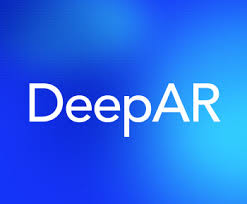

# Introducción

**[DeepAR](https://github.com/awslabs/gluonts)** es un modelo de forecasting o pronóstico que se basa en <font color='red'> redes neuronales profundas </font>, desarrollado por Amazon.\
Este modelo es parte de la familia de modelos probabilísticos y está diseñado para realizar predicciones de series temporales. \
A diferencia de los enfoques tradicionales, como los modelos ARIMA o Holt-Winters, que pueden tener dificultades con patrones complejos y no lineales, DeepAR aprovecha el poder de las redes neuronales para capturar dependencias no lineales y aprender patrones complejos en los datos.

¿Por qué DeepAR?: Tradicionalmente, los modelos de predicción de series temporales se basaban en reglas estadísticas fijas, como ARIMA. Sin embargo, esos métodos pueden tener dificultades para manejar patrones no lineales, cambios repentinos o dependencias a largo plazo. DeepAR resuelve estos problemas mediante redes neuronales recurrentes (RNNs), como las LSTM o GRU, que son capaces de aprender patrones complejos y no lineales de manera más eficiente.

## Arquitectura  

DeepAR utiliza un enfoque basado en redes neuronales recurrentes. Aquí te doy un esquema básico de cómo funciona:

✅**Entrada:** Recibe las series temporales de entrenamiento. Estas series pueden tener diferentes frecuencias y longitudes. Para cada serie temporal, se pueden incorporar características adicionales (como variables externas que puedan influir en las predicciones, como el clima, campañas de marketing, etc.).

✅ **Red Neuronal Recurrente:** El modelo utiliza una red neuronal recurrente (RNN) como LSTM o GRU, que es capaz de manejar dependencias a largo plazo entre los valores de la serie temporal. Estas redes son particularmente buenas para problemas secuenciales, como las series temporales, porque mantienen una "memoria" del pasado.

✅ **Predicción Probabilística:** DeepAR no solo predice un valor puntual (como la venta del próximo día), sino que genera una distribución de probabilidad para cada valor futuro. Esto es útil porque, en la práctica, las predicciones de series temporales no siempre son exactas, y tener una distribución permite manejar la incertidumbre.

✅ **Out-of-Sample Prediction:** DeepAR puede generar predicciones no solo para las series temporales conocidas, sino también para nuevas series o productos que no han sido entrenados previamente, lo que lo hace muy útil para pronosticar cosas como la demanda de productos en nuevas tiendas.

#Ventajas de DeepAR:

📌 **Captura de complejidad no lineal:** A diferencia de los modelos tradicionales, DeepAR puede manejar relaciones no lineales en los datos.

📌 **Predicciones probabilísticas:** Nos da más que una simple predicción puntual, permitiendo capturar la incertidumbre y ofrecer un rango de valores posibles.

📌**Modelado multivariante:** Puede manejar series temporales con diferentes características y variables adicionales.

# Instalación

In [ ]:
! pip --q install gluonts
! pip --q install lightning
!pip  --q install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.9/818.9 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

# Carga de librerias

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive
from google.colab import files
import matplotlib.pyplot as plt
import zipfile

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import max_error

from gluonts.dataset.pandas import PandasDataset
from gluonts.torch.model.deepar import DeepAREstimator

import os
import warnings

warnings.filterwarnings("ignore")

# Funciones

In [ ]:
def wmape(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()

def errores( reales, prediccion):
  s=[]
  s.append(['r2_score' ,r2_score(reales, prediccion)])
  s.append(['mean_absolute_error' ,mean_absolute_error(reales, prediccion)])
  s.append(['mean_squared_error' ,mean_squared_error(reales, prediccion)])
  s.append(['mean_absolute_percentage_error' ,mean_absolute_percentage_error(reales, prediccion)])
  s.append(['max_error' ,max_error(reales, prediccion)])
  s=pd.DataFrame(s)
  s.columns=['metrica', 'valor']
  return s

In [ ]:

def detectar_nulos_por_categoria(df, fecha_col, valor_col, categoria_col):
    """
    Verifica si hay valores nulos en una serie de tiempo con frecuencia diaria por categoría.

    Parámetros:
    df : pd.DataFrame -> DataFrame con los datos
    fecha_col : str -> Nombre de la columna con fechas
    valor_col : str -> Nombre de la columna con los valores
    categoria_col : str -> Nombre de la columna con categorías

    Retorna:
    - Un DataFrame con la cantidad de valores nulos por categoría.
    """
    # Convertir a datetime si no lo es
    df[fecha_col] = pd.to_datetime(df[fecha_col])

    # Crear un DataFrame vacío para almacenar los resultados
    resultados = []

    # Iterar sobre cada categoría
    for categoria, grupo in df.groupby(categoria_col):
        # Reindexar la serie temporal a frecuencia diaria
        grupo = grupo.set_index(fecha_col).asfreq('D')

        # Contar valores nulos
        nulos = grupo[valor_col].isna().sum()

        # Guardar el resultado
        resultados.append({categoria_col: categoria, 'nulos': nulos})

    return pd.DataFrame(resultados)



def completar_fechas_faltantes(df, fecha_col, valor_col, categoria_col, fill_value=0):
    """
    Completa las fechas faltantes en la serie de tiempo con un valor dado.

    Parámetros:
    df : pd.DataFrame -> DataFrame con los datos
    fecha_col : str -> Nombre de la columna con fechas
    valor_col : str -> Nombre de la columna con los valores
    categoria_col : str -> Nombre de la columna con categorías
    fill_value : cualquier tipo -> Valor con el que se llenarán las fechas faltantes (default=2)

    Retorna:
    - DataFrame con las fechas faltantes completadas.
    """
    df[fecha_col] = pd.to_datetime(df[fecha_col])

    categorias = df[categoria_col].unique()
    min_fecha, max_fecha = df[fecha_col].min(), df[fecha_col].max()

    fechas_completas = pd.date_range(start=min_fecha, end=max_fecha, freq='D')

    df_completo = pd.DataFrame()

    for categoria in categorias:
        df_cat = df[df[categoria_col] == categoria].set_index(fecha_col)
        df_cat = df_cat.reindex(fechas_completas, fill_value=fill_value).reset_index()
        df_cat.rename(columns={'index': fecha_col}, inplace=True)
        df_cat[categoria_col] = categoria
        df_completo = pd.concat([df_completo, df_cat], ignore_index=True)

    return df_completo

In [ ]:
def dividir_datos(df, fecha_col, test_size=0.2):
    """
    Divide los datos en conjuntos de entrenamiento y prueba basándose en la columna de fecha.

    Parámetros:
    df : pd.DataFrame -> DataFrame con los datos
    fecha_col : str -> Nombre de la columna con fechas
    test_size : float -> Proporción de datos a usar para prueba (default=0.2)

    Retorna:
    - DataFrame de entrenamiento
    - DataFrame de prueba
    """
    df[fecha_col] = pd.to_datetime(df[fecha_col])

    min_fecha = df[fecha_col].min()
    max_fecha = df[fecha_col].max()

    split_fecha = min_fecha + (max_fecha - min_fecha) * (1 - test_size)

    train = df[df[fecha_col] <= split_fecha]
    test = df[df[fecha_col] > split_fecha]

    return train, test

In [ ]:
def generar_predicciones(pred, frecuencia, fecha_col, categoria_col, test):
    """
    Genera un DataFrame con predicciones a partir de muestras y calcula percentiles.

    Parámetros:
    pred : iterable -> Lista de objetos con atributos item_id, samples y start_date
    frecuencia : str -> Frecuencia de la serie temporal (ej. 'D' para diaria)
    fecha_col : str -> Nombre de la columna de fechas
    categoria_col : str -> Nombre de la columna de categorías
    test : pd.DataFrame -> DataFrame de prueba para la comparación

    Retorna:
    - DataFrame con predicciones y percentiles
    """
    all_preds = []

    for item in pred:
        family = item.item_id
        p = item.samples.mean(axis=0)
        p10 = np.percentile(item.samples, 10, axis=0)
        p90 = np.percentile(item.samples, 90, axis=0)
        dates = pd.date_range(start=item.start_date.to_timestamp(), periods=len(p), freq=frecuencia)

        family_pred = pd.DataFrame({
            fecha_col: dates,
            categoria_col: family,
            'pred': p,
            'p10': p10,
            'p90': p90
        })

        all_preds.append(family_pred)

    all_preds = pd.concat(all_preds, ignore_index=True)
    all_preds = all_preds.merge(test, on=[fecha_col, categoria_col], how='left')

    return all_preds


In [ ]:


def grafica_plt(df, column_time, colum_value, forecast=None, column_time2=None, colum_value2=None, titley='vacio', title='Gráfico de Predicción'):
    import plotly.express as px
    import plotly.graph_objects as go
    """
    Genera una gráfica interactiva de series temporales.

    Parámetros:
    df : pd.DataFrame -> DataFrame con datos reales
    column_time : str -> Nombre de la columna de tiempo para los datos reales
    colum_value : str -> Nombre de la columna de valores reales
    forecast : pd.DataFrame (opcional) -> DataFrame con predicciones
    column_time2 : str (opcional) -> Nombre de la columna de tiempo en el DataFrame de predicciones
    colum_value2 : str (opcional) -> Nombre de la columna de valores de predicción
    title : str -> Título del gráfico con formato HTML (negrilla y salto de línea)

    Retorna:
    - Gráfico interactivo
    """
    fig = go.Figure()

    # Agregar serie de datos reales
    fig.add_trace(go.Scatter(x=df[column_time], y=df[colum_value], name='Reales',
                             line=dict(color='olive', width=3, dash='dash')))

    # Agregar serie de predicciones si está disponible
    if forecast is not None and column_time2 is not None and colum_value2 is not None:
        fig.add_trace(go.Scatter(x=forecast[column_time2], y=forecast[colum_value2], name='Predicción',
                                 line=dict(color='#8C000F', width=3, dash='dash')))

        # Agregar intervalo de confianza
        fig.add_trace(go.Scatter(
            x=forecast[column_time2].tolist() + forecast[column_time2].tolist()[::-1],
            y=forecast['p90'].tolist() + forecast['p10'].tolist()[::-1],
            fill='toself',
            fillcolor='rgba(255, 165, 0, 0.2)',
            line=dict(color='rgba(255,255,255,0)'),
            showlegend=True,
            name='Intervalo de Confianza (10-90%)'
        ))

    # Configurar el diseño del gráfico con título en HTML
    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            y=0.95,
            font=dict(size=16)
        ),
        xaxis_title="Día de la semana",
        yaxis_title=titley,
        xaxis=dict(rangeslider=dict(visible=True),
                  rangeselector=dict(
                      buttons=list([
                          dict(count=1, label="1m", step="month", stepmode="backward"),
                          dict(count=6, label="6m", step="month", stepmode="backward"),
                          dict(count=1, label="YTD", step="year", stepmode="todate"),
                          dict(count=1, label="1y", step="year", stepmode="backward"),
                          dict(step="all")
                      ])
                  )
        )
    )

    return fig.show()

# Conexion Drive

In [ ]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Parametros

In [ ]:
fecha_col= 'date'
valor_col='sales'
categoria_col= 'family'
frecuencia= 'D'
titley='sales'

### Contextos de los datos

Las ventas de las tiendas basándose en datos de Corporación Favorita, un gran minorista de comestibles con sede en Ecuador.

In [ ]:
zip_path = "/content/drive/MyDrive/University/Cursos/Planeacion_Demanda_Pronosticos/Datos_Clase/DeeAR.zip"  # Ruta del archivo zip

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    with zip_ref.open("train.csv") as file:
        df = pd.read_csv(file,  index_col='id', parse_dates=['date']).reset_index(drop=True)  # Carga el CSV en un DataFrame
        df = df.loc[df['store_nbr'] == 1, ['date', 'family', 'sales']]
        print(df.head())  # Muestra las primeras filas

familias = df['family'].unique()


        date      family  sales
0 2013-01-01  AUTOMOTIVE    0.0
1 2013-01-01   BABY CARE    0.0
2 2013-01-01      BEAUTY    0.0
3 2013-01-01   BEVERAGES    0.0
4 2013-01-01       BOOKS    0.0


In [ ]:
detectar_nulos_por_categoria(df, fecha_col, valor_col,categoria_col).head(3)

,family,nulos
0,AUTOMOTIVE,4
1,BABY CARE,4
2,BEAUTY,4


In [ ]:
df_completado= completar_fechas_faltantes(df, fecha_col, valor_col, categoria_col)

df_completado.head(3)

,date,family,sales
0,2013-01-01,AUTOMOTIVE,0.0
1,2013-01-02,AUTOMOTIVE,2.0
2,2013-01-03,AUTOMOTIVE,3.0


In [ ]:
detectar_nulos_por_categoria(df_completado, fecha_col, valor_col,categoria_col).head(2)

,family,nulos
0,AUTOMOTIVE,0
1,BABY CARE,0


División del conjunto de datos en entrenamiento y test.
Considerando un 80% para Train y por consiguiente 20% Test

In [ ]:
train, test= dividir_datos(df_completado, fecha_col, test_size=0.2)

In [ ]:
train_ds = PandasDataset.from_long_dataframe(train, target=valor_col, item_id=categoria_col,
                                       timestamp=fecha_col, freq=frecuencia)

# Entrenamiento

In [ ]:
estimator = DeepAREstimator(freq=frecuencia, prediction_length=90, num_layers=3, trainer_kwargs={'accelerator': 'gpu', 'max_epochs':30})

predictor = estimator.train(train_ds, num_workers=2)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name  | Type        | Params | Mode  | In sizes                                                         | Out sizes   
--------------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 39.0 K | train | [[1, 1], [1, 1], [1, 1182, 4], [1, 1182], [1, 1182], [1, 90, 4]] | [1, 100, 90]
------------------------------------------------------------------------------------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

INFO: Epoch 0, global step 50: 'train_loss' reached 0.94502 (best 0.94502), saving model to '/content/lightning_logs/version_0/checkpoints/epoch=0-step=50.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 0, global step 50: 'train_loss' reached 0.94502 (best 0.94502), saving model to '/content/lightning_logs/version_0/checkpoints/epoch=0-step=50.ckpt' as top 1
INFO: Epoch 1, global step 100: 'train_loss' reached 0.34701 (best 0.34701), saving model to '/content/lightning_logs/version_0/checkpoints/epoch=1-step=100.ckpt' as top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 1, global step 100: 'train_loss' reached 0.34701 (best 0.34701), saving model to '/content/lightning_logs/version_0/checkpoints/epoch=1-step=100.ckpt' as top 1
INFO: Epoch 2, global step 150: 'train_loss' was not in top 1
INFO:lightning.pytorch.utilities.rank_zero:Epoch 2, global step 150: 'train_loss' was not in top 1
INFO: Epoch 3, global step 200: 'train_loss' was not in top 1
INFO:lightning.pyto

Ahora que se tiene el modelo entrenado, se puede proceder a hacer la predicción de la misma.

In [ ]:
pred = list(predictor.predict(train_ds))

In [ ]:
df_salida = generar_predicciones(pred, frecuencia, fecha_col, categoria_col, test)
df_salida.head(2)

,date,family,pred,p10,p90,sales
0,2016-09-12,AUTOMOTIVE,2.738727,-0.494173,7.125074,4.0
1,2016-09-13,AUTOMOTIVE,4.215872,-0.382073,7.404182,4.0


In [ ]:
for f in familias:
  df_familiy_salida=df_salida[df_salida[categoria_col]==f]
  titulo='Predicción de <b>'+f+'</b><br>con DeepAR'

  grafica_plt(df_familiy_salida, fecha_col, valor_col, forecast=df_familiy_salida, column_time2=fecha_col, colum_value2='pred',titley=titley, title=titulo )


In [ ]:
sali=[]
for family in df_salida[categoria_col].unique():
  df_familiy_salida=df_salida[df_salida[categoria_col]==family]
  previo= errores( df_familiy_salida[valor_col], df_familiy_salida ['pred'])
  previo['family']=family
  sali.append(previo)

sali_metricas=pd.concat(sali)
sali_metricas

,metrica,valor,family
0,r2_score,-2.566529e-01,AUTOMOTIVE
1,mean_absolute_error,2.309757e+00,AUTOMOTIVE
2,mean_squared_error,8.451534e+00,AUTOMOTIVE
3,mean_absolute_percentage_error,6.881194e+14,AUTOMOTIVE
4,max_error,7.646492e+00,AUTOMOTIVE
...,...,...,...
0,r2_score,1.417706e-01,SEAFOOD
1,mean_absolute_error,7.768857e+00,SEAFOOD
2,mean_squared_error,9.153256e+01,SEAFOOD
3,mean_absolute_percentage_error,3.495670e-01,SEAFOOD
